In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('C:\\Users\\Priyavarshini\\OneDrive\\Desktop\\GUVI\\Project 3 ML\\Fitbit_dataset.csv')

In [3]:
df.head(2)

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5


In [4]:
df.columns

Index(['Unnamed: 0', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM',
       'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)'],
      dtype='object')

In [5]:
df.shape

(14102, 19)

In [6]:
df.describe()

,Unnamed: 0,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
count,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000
mean,7050.500000,38.528365,68.252922,1.680338,181.400794,147.955538,69.333073,0.830135,21.844313,3.598624,4.150262,1.150546,24.092838,6.726918,0.701554,4.924756,279.492866
std,4071.041083,12.007994,13.330332,0.097543,12.913603,14.628858,7.110206,0.288531,5.974424,0.626391,1.650013,1.057974,3.776271,2.180444,0.100263,2.124242,172.858430
min,0.000000,18.000000,37.800000,1.450000,150.000000,109.000000,55.000000,0.250000,8.000000,1.500000,2.000000,0.000000,18.000000,3.000000,0.539474,1.618421,18.400000
25%,3525.250000,28.000000,58.400000,1.610000,171.000000,137.000000,64.000000,0.620000,17.700000,3.200000,3.000000,0.000000,21.200000,6.000000,0.648000,4.187500,143.200000
50%,7050.500000,39.000000,67.300000,1.680000,181.000000,147.000000,70.000000,0.820000,22.000000,3.600000,4.000000,1.000000,24.000000,7.000000,0.700000,4.550000,251.050000
75%,10575.750000,49.000000,77.000000,1.750000,192.000000,158.000000,75.000000,1.030000,26.100000,4.000000,5.000000,2.000000,26.700000,8.000000,0.752475,6.019802,373.700000
max,14101.000000,59.000000,125.100000,1.900000,205.000000,187.000000,85.000000,1.900000,40.000000,5.900000,7.000000,3.000000,35.000000,9.500000,0.860215,8.172043,1442.400000


In [7]:
df.drop(columns='Unnamed', inplace=True, errors='ignore')
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

Encoding

In [8]:
df['Gender'] = df['Gender'].str.strip()
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
print(df['Gender'].head())

0    0
1    1
2    0
3    1
4    1
Name: Gender, dtype: int64


In [9]:
df = pd.get_dummies(df, columns=['Workout_Type'], prefix='Type')

In [10]:
df.head(5)

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,...,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),Type_Cardio,Type_HIIT,Type_Mixed,Type_Strength,Type_Yoga
0,0,56,0,53.8,1.62,163.0,149.0,71.0,1.01,22.1,...,20.4,9.5,0.847826,8.054348,437.7,False,True,False,False,False
1,1,46,1,54.9,1.75,170.0,126.0,73.0,0.25,19.9,...,18.0,3.0,0.546392,1.639175,22.5,False,False,False,False,True
2,2,32,0,68.5,1.61,190.0,171.0,60.0,0.33,20.4,...,26.5,9.5,0.853846,8.111538,183.4,False,True,False,False,False
3,3,25,1,98.8,1.86,189.0,135.0,69.0,0.78,30.3,...,28.5,3.0,0.550000,1.650000,127.2,False,False,False,False,True
4,4,38,1,95.5,1.71,176.0,138.0,66.0,0.55,23.7,...,32.5,7.0,0.654545,4.581818,240.7,True,False,False,False,False


Outliers and Capping

In [ ]:
num_cols = ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 
            'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 
            'Water_Intake (liters)', 'BMI', 'Calories_Burned (kcal)']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

Feature Scaling : Standard Scaler

In [12]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [13]:
import sklearn

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Calories_Burned (kcal)', 'Unnamed: 0'], errors='ignore')
y = df['Calories_Burned (kcal)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

In [18]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "SVR": SVR()
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, predictions)
    
    results.append({
        "Model": name,
        "R2 Score": r2_score(y_test, predictions),
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mse)
    })
    
evaluation_scores = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(evaluation_scores)

,Model,R2 Score,MAE,RMSE
5,Random Forest,0.998212,3.657630,7.118338
6,XGBoost,0.997848,5.127160,7.810152
4,Decision Tree,0.994806,7.673431,12.133120
3,KNN,0.945538,28.248259,39.290657
0,Linear,0.926260,31.761451,45.718677
1,Ridge,0.926246,31.760443,45.722915
2,Lasso,0.923883,32.114785,46.449538
7,SVR,0.920384,27.872229,47.505269


**Induvidual Evaluation**

Linear Regression

In [21]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [22]:
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression R2: {r2_lr:.4f}")
print(f"MAE: {mae_lr:.2f} kcal")

Linear Regression R2: 0.9263
MAE: 31.76 kcal


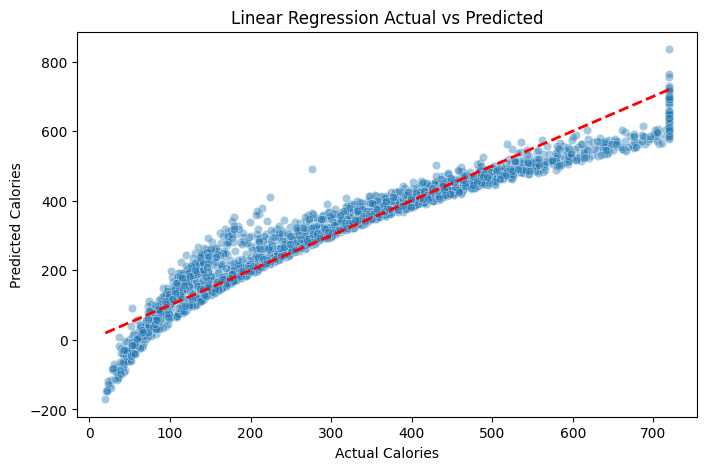

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_test, y = y_pred_lr, alpha = 0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Linear Regression Actual vs Predicted")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

Ridge Regression

In [24]:
ridge_reg = Ridge()
ridge_reg.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_reg.predict(X_test_scaled)

r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

print(f"Ridge Regression R2: {r2_ridge : .4f}")
print(f"MAE: {mae_ridge:.2f} kcal")
print(f"MSE : {mse_ridge}")
print(f"RMSE : {rmse_ridge}")

Ridge Regression R2:  0.9262
MAE: 31.76 kcal
MSE : 2090.584953641474
RMSE : 45.72291497314529


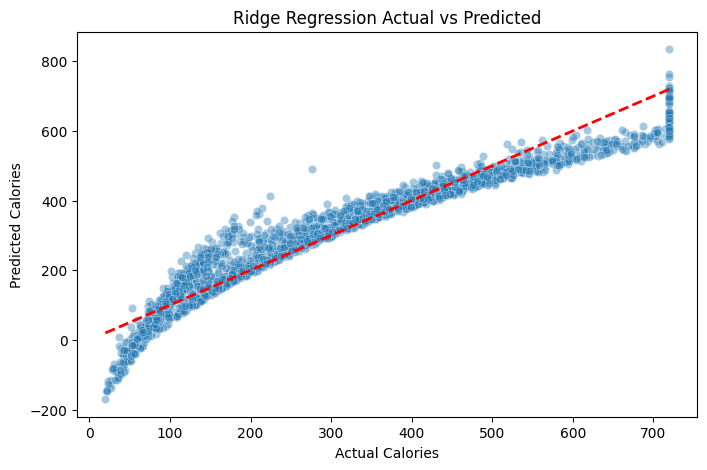

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_test, y = y_pred_ridge, alpha = 0.4) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Ridge Regression Actual vs Predicted")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

Lasso Regression

In [26]:
lasso_reg = Lasso()
lasso_reg.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_reg.predict(X_test_scaled)

r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

print(f"lasso Regression R2: {r2_lasso : .4f}")
print(f"MAE: {mae_lasso:.2f} kcal")
print(f"MSE : {mse_lasso}")
print(f"RMSE : {rmse_lasso}")

lasso Regression R2:  0.9239
MAE: 32.11 kcal
MSE : 2157.559549285748
RMSE : 46.44953766492997


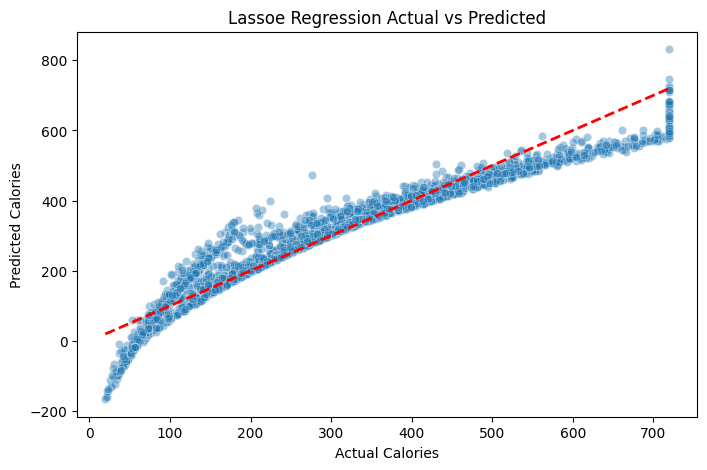

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_test, y = y_pred_lasso, alpha = 0.4) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Lassoe Regression Actual vs Predicted")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

XGBoost Regressor

XGBoost R2 Score: 0.9978
MAE: 5.13 kcal
MSE : 60.998478491630415
RMSE: 7.81 kcal


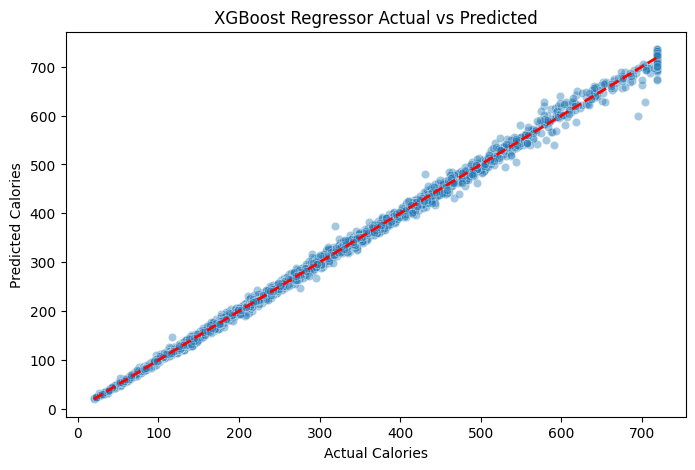

In [28]:
xgb_default = XGBRegressor(random_state=42)
xgb_default.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_default.predict(X_test_scaled)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost R2 Score: {r2_xgb:.4f}")
print(f"MAE: {mae_xgb:.2f} kcal")
print(f"MSE : {mse_xgb}")
print(f"RMSE: {rmse_xgb:.2f} kcal")

plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_test, y = y_pred_xgb, alpha = 0.4) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("XGBoost Regressor Actual vs Predicted")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

K-Nearest Neighbors (KNN) Regressor


KNN Regression R2:  0.9455
MAE: 28.25 kcal
MSE : 1543.7557217298834
RMSE : 39.29065692667766


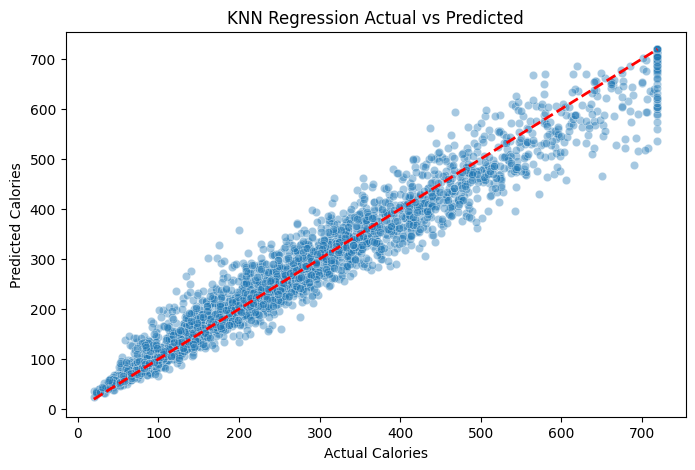

In [29]:
knn = KNeighborsRegressor(n_neighbors= 5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

r2_knn = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)

print(f"KNN Regression R2: {r2_knn : .4f}")
print(f"MAE: {mae_knn:.2f} kcal")
print(f"MSE : {mse_knn}")
print(f"RMSE : {rmse_knn}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_test, y = y_pred_knn, alpha = 0.4) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("KNN Regression Actual vs Predicted")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

Decision Tree Regressor R2:  0.9952
MAE: 7.51 kcal
MSE : 134.81306097128677
RMSE : 11.610902676850184


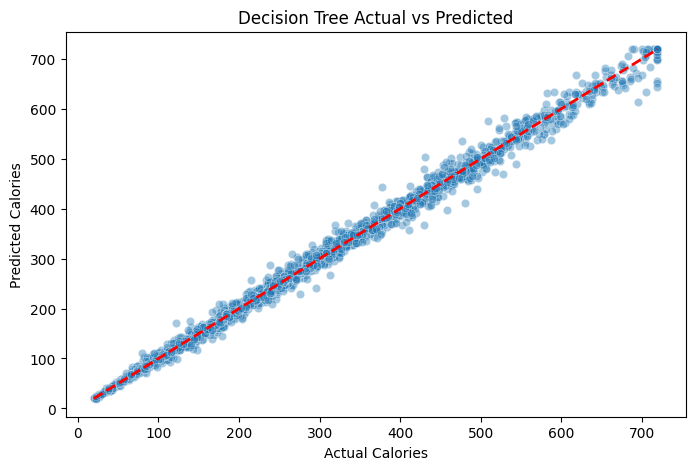

In [30]:
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_scaled, y_train)

y_pred_dt = dt_reg.predict(X_test_scaled)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print(f"Decision Tree Regressor R2: {r2_dt : .4f}")
print(f"MAE: {mae_dt:.2f} kcal")
print(f"MSE : {mse_dt}")
print(f"RMSE : {rmse_dt}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_test, y = y_pred_dt, alpha = 0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Decision Tree Actual vs Predicted")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

Random Forest Regressor R2:  0.9982
MAE: 3.66 kcal
MSE : 50.67073722057804
RMSE : 7.1183380940060745


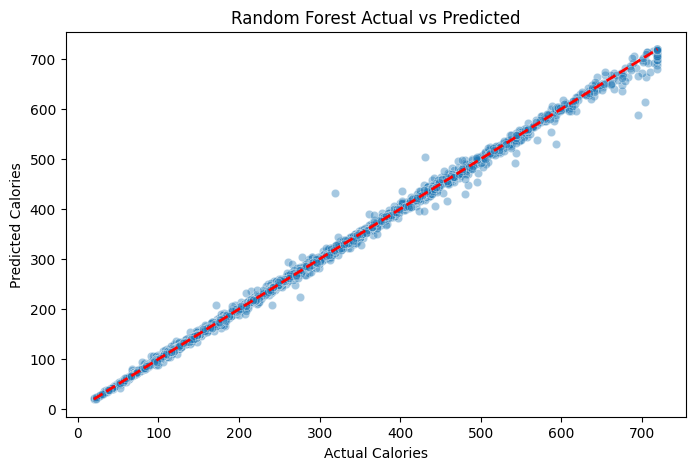

In [31]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train)

y_pred_rf = rf_reg.predict(X_test_scaled)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"Random Forest Regressor R2: {r2_rf : .4f}")
print(f"MAE: {mae_rf:.2f} kcal")
print(f"MSE : {mse_rf}")
print(f"RMSE : {rmse_rf}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_test, y = y_pred_rf, alpha = 0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Random Forest Actual vs Predicted")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

Support Vector Regressor R2:  0.9979
MAE: 2.75 kcal
MSE : 58.64522229529006
RMSE : 7.658016864390549


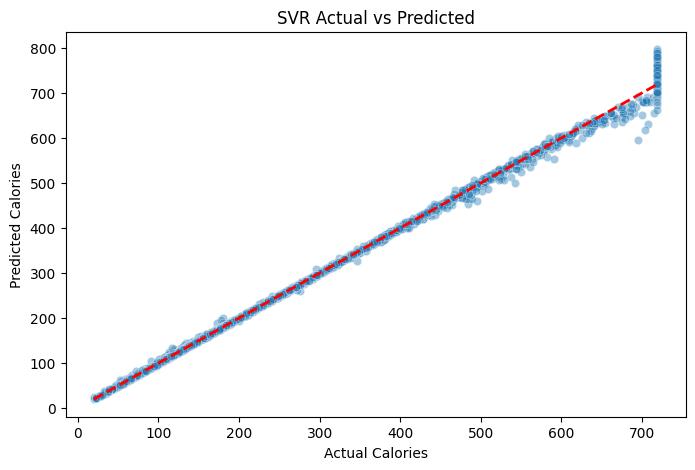

In [32]:
svr_reg = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_reg.fit(X_train_scaled, y_train)

y_pred_svr = svr_reg.predict(X_test_scaled)

r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print(f"Support Vector Regressor R2: {r2_svr : .4f}")
print(f"MAE: {mae_svr:.2f} kcal")
print(f"MSE : {mse_svr}")
print(f"RMSE : {rmse_svr}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_test, y = y_pred_svr, alpha = 0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("SVR Actual vs Predicted")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

Data Leakage Testing

In [33]:
leaky_cols = ['Base_MET', 'Effective_MET', 'HR_Intensity']

X_clean = X.drop(columns=leaky_cols, errors='ignore')

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

rf_clean = RandomForestRegressor(n_estimators=100, random_state=42)
rf_clean.fit(X_train_c_scaled, y_train_c)
clean_score = rf_clean.score(X_test_c_scaled, y_test_c)

print(f"Score WITH MET columns: 0.9982")
print(f"Score WITHOUT MET columns: {clean_score:.4f}")

Score WITH MET columns: 0.9982
Score WITHOUT MET columns: 0.9983


In [ ]:
from sklearn.model_selection import GridSearchCV

tuning_setup = {
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            'n_estimators': [50, 100],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42),
        "params": {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            'kernel': ['rbf', 'linear'],
            'C': [0.1, 1, 10],
            'epsilon': [0.01, 0.1]
        }
    }
}

tuned_results = []

print("Hyperparameter Tuning :\n")

for name, setup in tuning_setup.items():
    print(f"Tuning {name}...")
    
    grid_search = GridSearchCV(estimator=setup["model"], 
                               param_grid=setup["params"], 
                               cv=3, 
                               scoring='r2', 
                               n_jobs=-1)
    
    grid_search.fit(X_train_scaled, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred_tuned = best_model.predict(X_test_scaled)
    final_r2 = r2_score(y_test, y_pred_tuned)
    
    tuned_results.append({
        "Model": name,
        "Tuned R2 Score": final_r2,
        "Best Parameters": grid_search.best_params_
    })

tuned_leaderboard = pd.DataFrame(tuned_results).sort_values(by="Tuned R2 Score", ascending=False)
display(tuned_leaderboard)

Hyperparameter Tuning...

Tuning KNN...
Tuning Decision Tree...
Tuning Random Forest...
Tuning XGBoost...
Tuning SVR...


,Model,Tuned R2 Score,Best Parameters
3,XGBoost,0.998859,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti..."
2,Random Forest,0.998212,"{'max_depth': None, 'min_samples_split': 2, 'n..."
1,Decision Tree,0.995168,"{'max_depth': 20, 'min_samples_split': 5}"
4,SVR,0.992076,"{'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}"
0,KNN,0.946959,"{'n_neighbors': 7, 'weights': 'distance'}"


Saving the Tuned and Untuned Models as Pickle file

In [37]:
import pickle

In [40]:
xgb_tuned = XGBRegressor(learning_rate=0.1, max_depth=7, n_estimators=100, random_state=42)
xgb_tuned.fit(X_train_scaled, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [41]:
rf_tuned = RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_split=2, random_state=42)
rf_tuned.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [42]:
dt_tuned = DecisionTreeRegressor(max_depth=20, min_samples_split=5, random_state=42)
dt_tuned.fit(X_train_scaled, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [43]:
svr_tuned = SVR(C=10, epsilon=0.1, kernel='rbf')
svr_tuned.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [44]:
knn_tuned = KNeighborsRegressor(n_neighbors=7, weights='distance')
knn_tuned.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
model_columns = X_train.columns.tolist()
pickle.dump(model_columns, open('../pickles/model_columns.pkl', 'wb'))
pickle.dump(scaler, open('../pickles/scaler_supervised.pkl', 'wb'))

In [ ]:
pickle.dump(xgb_tuned, open('../pickles/xgb_tuned.pkl', 'wb'))
pickle.dump(rf_tuned, open('../pickles/rf_tuned.pkl', 'wb'))
pickle.dump(dt_tuned, open('../pickles/dt_tuned.pkl', 'wb'))
pickle.dump(svr_tuned, open('../pickles/svr_tuned.pkl', 'wb'))
pickle.dump(knn_tuned, open('../pickles/knn_tuned.pkl', 'wb'))
pickle.dump(lr, open('../pickles/lr.pkl', 'wb'))
pickle.dump(ridge_reg, open('../pickles/ridge_reg.pkl', 'wb'))
pickle.dump(lasso_reg, open('../pickles/lasso_reg.pkl', 'wb'))
pickle.dump(xgb_default, open('../pickles/xgb_default.pkl', 'wb'))
pickle.dump(knn, open('../pickles/knn.pkl', 'wb'))
pickle.dump(dt_reg, open('../pickles/dt_reg.pkl', 'wb'))
pickle.dump(rf_reg, open('../pickles/rf_reg.pkl', 'wb'))
pickle.dump(svr_reg, open('../pickles/svr_reg.pkl', 'wb'))